<a href="https://colab.research.google.com/github/zjpza/fase6-cap1/blob/main/notebooks/JoaoPedroZavanelaAndreu_rm570231_pbl_fase6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PBL Fase 6 – Visão Computacional com YOLO
**Notebook:** João Pedro Zavanela Andreu · RM 570231 — `JoaoPedroZavanelaAndreu_rm570231_pbl_fase6.ipynb` (padrão do barema)
**Conteúdo (seções 1–7):** Patrick Borges Melo · RM 574030 · **Classes:** `vaca` (0) e `caminhao` (1)

> Rodar no Google Colab com GPU. As seções 2–7 dependem do dataset no Drive (`Espaço Matopiba / Fase 6 - Cap 1 / dataset`).

## 1. Ambiente (rodar no Google Colab, com GPU: *Ambiente de execução → Alterar tipo → GPU*)

In [10]:
# Monta o Google Drive da conta que executa o notebook: é onde vivem o dataset e a pasta de resultados
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# Clona o YOLOv5 só se ainda não estiver no disco (/content sobrevive ao "Reiniciar e executar tudo")
![ -d /content/yolov5 ] || git clone --depth 1 https://github.com/ultralytics/yolov5 /content/yolov5
# As células 18 e 20 usam caminhos relativos (runs/...), então o diretório de trabalho importa
%cd /content/yolov5
# Dependências do YOLOv5 (o Colab já traz torch/CUDA)
!pip install -q -r requirements.txt
# Confere a GPU: sem GPU o treino de 100 épocas fica inviável
import torch; print(torch.__version__, 'GPU:', torch.cuda.is_available())

/content/yolov5
2.11.0+cu130 GPU: True


## 2. Dataset (Issues #1 e #2)
O dataset está na pasta **dataset** do Drive do grupo (a pasta mãe é **Fase 6 - Cap 1**, compartilhada em modo *qualquer pessoa com o link*; dona: `rm574030.fiap`), com `images/` e `labels/` em train/val/test. A célula abaixo usa a cópia montada quando ela existe e, se não existir, baixa a pasta pública com `gdown` — sem depender de login, o que faz o notebook rodar em qualquer conta, inclusive na correção. O `data.yaml` é reescrito apontando para a cópia local em `/content/dataset`, bem mais rápida que ler direto do Drive.

In [12]:
# Obtém o dataset: copia da pasta montada quando ela existe, senão baixa pela API do Drive
import glob, os, shutil

DRIVE_DATASET_ID = '1sd36wCw_DFbHvUJQ5rCEoY0kv68eD0WU'  # pasta "dataset" do grupo no Drive (pública: qualquer pessoa com o link)
DRIVE_FOLDER_ID = '1rsR8mIwdqTlEC4d_ehCpaMtONiEjv5vz'  # pasta "Fase 6 - Cap 1" (usada no fallback 3)
LOCAL = '/content/dataset'

# 1) O caminho no mount varia (Meu Drive, Drive compartilhado ou atalho): testa candidatos e uma busca rasa
CANDIDATOS = [
    '/content/drive/MyDrive/Espaço Matopiba/Fase 6 - Cap 1/dataset',
    '/content/drive/MyDrive/Fase 6 - Cap 1/dataset',
    '/content/drive/MyDrive/dataset',
    '/content/drive/Shareddrives/Espaço Matopiba/Fase 6 - Cap 1/dataset',
    '/content/drive/Shareddrives/Fase 6 - Cap 1/dataset',
]
for raiz in ('/content/drive/MyDrive', '/content/drive/Shareddrives'):
    CANDIDATOS += glob.glob(f'{raiz}/*/dataset') + glob.glob(f'{raiz}/*/*/dataset')
DRIVE_DATASET = next((p for p in CANDIDATOS if os.path.isdir(f'{p}/images/train')), None)

if os.path.exists(LOCAL): shutil.rmtree(LOCAL)  # descarta a cópia anterior

if DRIVE_DATASET:
    shutil.copytree(DRIVE_DATASET, LOCAL)
    print('dataset copiado da pasta montada:', DRIVE_DATASET)
else:
    # 2) Pasta pública no Drive: o gdown baixa sem login, mas o Google limita a 50 arquivos por pasta
    #    (a nossa tem 164), então na prática o passo 3 assume — a mensagem "Failed to retrieve" é esperada
    !pip install -q gdown
    !gdown --folder https://drive.google.com/drive/folders/{DRIVE_DATASET_ID} -O /content/gdown_tmp --quiet
    if os.path.isdir('/content/gdown_tmp'):
        os.makedirs(LOCAL, exist_ok=True)
        for item in os.listdir('/content/gdown_tmp'):  # o gdown grava o conteúdo da pasta no diretório de saída
            shutil.move(f'/content/gdown_tmp/{item}', f'{LOCAL}/{item}')
        shutil.rmtree('/content/gdown_tmp')
        print('dataset baixado da pasta pública do Drive (gdown)')

if not os.path.isdir(f'{LOCAL}/images/train'):
    # 3) Pasta apenas compartilhada com o grupo ("Compartilhados comigo") não aparece no mount do Colab:
    # baixamos pela API do Drive com a conta que executa o notebook (o Colab pede autorização aqui)
    from google.colab import auth
    from googleapiclient.discovery import build
    from googleapiclient.http import MediaIoBaseDownload
    auth.authenticate_user()
    svc = build('drive', 'v3')

    def filhos(fid):
        """Lista o conteúdo de uma pasta do Drive, inclusive de pastas só compartilhadas."""
        return svc.files().list(q=f"'{fid}' in parents and trashed = false", pageSize=1000,
                                fields='files(id,name,mimeType)', supportsAllDrives=True,
                                includeItemsFromAllDrives=True).execute()['files']

    pasta = next((f for f in filhos(DRIVE_FOLDER_ID) if f['name'] == 'dataset'
                  and f['mimeType'] == 'application/vnd.google-apps.folder'), None)
    if pasta is None:
        raise FileNotFoundError(f"pasta 'dataset' não encontrada em {DRIVE_FOLDER_ID}: confira se a pasta do projeto está compartilhada com a conta que executa o notebook")

    baixados = []

    def baixa(fid, destino):
        """Desce a árvore de pastas gravando os arquivos (images/, labels/, data.yaml)."""
        for f in filhos(fid):
            alvo = f'{destino}/{f["name"]}'
            if f['mimeType'] == 'application/vnd.google-apps.folder':
                os.makedirs(alvo, exist_ok=True)
                baixa(f['id'], alvo)
            else:
                os.makedirs(destino, exist_ok=True)
                with open(alvo, 'wb') as arq:
                    dl = MediaIoBaseDownload(arq, svc.files().get_media(fileId=f['id'], supportsAllDrives=True))
                    pronto = False
                    while not pronto:
                        _, pronto = dl.next_chunk()
                baixados.append(alvo)

    baixa(pasta['id'], LOCAL)
    print(f'dataset baixado pela API do Drive: {len(baixados)} arquivos')

# pasta onde a célula de resultados grava no Drive (a mesma do dataset quando ela está montada)
DRIVE_ROOT = os.path.dirname(DRIVE_DATASET) if DRIVE_DATASET else '/content/drive/MyDrive/Fase 6 - Cap 1'

# data.yaml com caminho do Colab (sobrescreve o do Drive, que aponta para outro caminho)
open(f'{LOCAL}/data.yaml','w').write(f'''path: {LOCAL}
train: images/train
val: images/val
test: images/test
nc: 2
names:
  0: vaca
  1: caminhao
''')
# Confere a estrutura: cada imagem precisa do seu .txt, e as contagens esperadas são 64 / 8 / 8
for s in ('train','val','test'):
    im = len(os.listdir(f'{LOCAL}/images/{s}')); lb = len(os.listdir(f'{LOCAL}/labels/{s}'))
    cx = [0, 0]  # caixas por classe (0 = vaca, 1 = caminhao): evidência da composição do dataset
    for arq in os.listdir(f'{LOCAL}/labels/{s}'):
        with open(f'{LOCAL}/labels/{s}/{arq}') as f:
            for linha in f:
                if linha.strip(): cx[int(linha.split()[0])] += 1
    print(s, 'imagens', im, 'labels', lb, '| caixas: vaca', cx[0], 'caminhao', cx[1])

Failed to retrieve folder contents:

	The gdrive folder with url: https://drive.google.com/drive/folders/1zf
	AeoNl9qOYe2fNF4nOjyZG6U8gyjmVq?hl=en has more than 50 files, gdrive
	can't download more than this limit.

You can use `--remaining-ok` option to ignore this error.


dataset baixado pela API do Drive: 164 arquivos
train imagens 64 labels 64 | caixas: vaca 110 caminhao 36
val imagens 8 labels 8 | caixas: vaca 8 caminhao 4
test imagens 8 labels 8 | caixas: vaca 11 caminhao 4


Verificação rápida: cada imagem deve ter seu `.txt`, e as contagens esperadas são **64 / 8 / 8** (train/val/test).
A célula acima imprime também as **caixas por classe** — é dela que saem os totais usados nas conclusões.

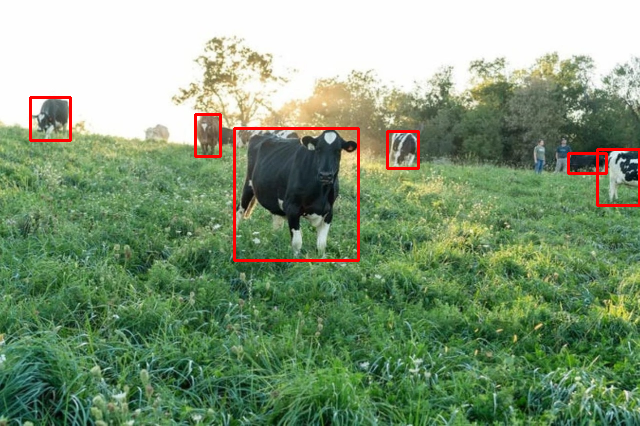

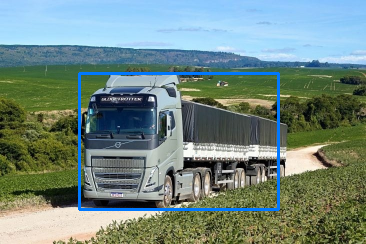

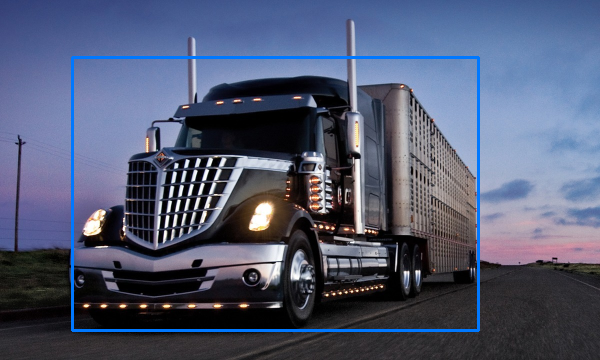

In [13]:
# Amostra visual: desenha as caixas rotuladas para conferir se o .txt casa com a imagem antes de treinar
import glob, os, random, cv2
from google.colab.patches import cv2_imshow
random.seed(0)  # amostra reprodutível entre execuções

def mostrar(split='train', n=3):
    """Mostra n imagens do split com as bounding boxes rotuladas (0 = vaca/vermelho, 1 = caminhão/azul)."""
    for p in random.sample(glob.glob(f'{LOCAL}/images/{split}/*'), n):
        im = cv2.imread(p); h, w = im.shape[:2]
        im = cv2.resize(im, (w//2, h//2))  # reduz antes de desenhar para a espessura não virar 1 pixel
        lab = os.path.splitext(p.replace('images', 'labels'))[0] + '.txt'  # aceita .jpg/.jpeg/.png
        for l in open(lab):
            c, cx, cy, bw, bh = l.split()  # classe cx cy w h (normalizados)
            cx, cy, bw, bh = float(cx)*w/2, float(cy)*h/2, float(bw)*w/2, float(bh)*h/2
            cv2.rectangle(im, (int(cx-bw/2), int(cy-bh/2)), (int(cx+bw/2), int(cy+bh/2)),
                          (0, 0, 255) if c == '0' else (255, 120, 0), 2)
        cv2_imshow(im)

mostrar()

## 3. YOLO tradicional (pré-treinado no COCO, sem treinar)
O COCO já tem `cow` (19) e `truck` (7). Rodamos o baseline **filtrado nessas duas classes** (`--classes 19 7`) para comparar o critério do COCO com o do nosso dataset; sem o filtro ele listaria também as outras 78 classes do COCO nas mesmas imagens.

In [14]:
# YOLOv5 pré-treinada no COCO (sem treinar) nas classes cow (19) e truck (7) — baseline da Entrega 2
!python detect.py --weights yolov5s.pt --source /content/dataset/images/test --classes 19 7 --conf 0.25 --name baseline_coco --exist-ok

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
detect: weights=['yolov5s.pt'], source=/content/dataset/images/test, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=[19, 7], agnostic_nms=False, augment=False, update=False, project=runs/detect, name=baseline_coco, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 f957879 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

100% 14.1M/14.1M [00:00<00:00, 351MB/s]

Fusing layers... 
YOLOv5s summary: 124 layers, 7,225,885 parameters, 0 gradients, 16.4 GFLOPs
im

## 4. YOLO customizado (treino)

**Passo a passo do treino** — fine-tuning de `yolov5s.pt` (pesos do COCO) nas nossas 2 classes:

1. `--data /content/dataset/data.yaml` — aponta os splits e os nomes das classes;
2. `--weights yolov5s.pt` — parte do modelo pré-treinado (transfer learning), não do zero;
3. `--img 640 --batch 16 --epochs 100` — resolução, lote e épocas que definem o custo do treino;
4. `--patience 30` — para cedo se a validação não melhorar por 30 épocas;
5. `--name vaca_caminhao` — grava tudo em `runs/train/vaca_caminhao/` (`best.pt`, `last.pt`, `results.csv`, gráficos).

O `best.pt` é escolhido pela **validação** a cada época; é ele que usamos no teste.

In [15]:
# Treino (fine-tuning) de 100 épocas na GPU T4 (~5 min); as métricas saem nas células seguintes
!python train.py --img 640 --batch 16 --epochs 100 --data /content/dataset/data.yaml --weights yolov5s.pt --patience 30 --name vaca_caminhao --exist-ok

WARNING ⚠️ wandb: wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
I0000 00:00:1791425054.124513   12418 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=, data=/content/dataset/data.yaml, hyp=data/hyps/hyp.scratch-low.yaml, epochs=100, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=run

> Os resultados do treino ficam em `runs/train/vaca_caminhao/` (não em `runs/detect/`).

## 5. Métricas

**Onde ler cada número:**

- `results.csv` / `results.png` — evolução por época (perdas `box`/`obj`/`cls` e P/R/mAP) no **treino** e na **validação**;
- `confusion_matrix.png` — em que classes o modelo confunde (vaca × caminhão × fundo);
- `val.py --task test` — métrica final no **teste**, usando o `best.pt` escolhido pela validação.

In [16]:
# Últimas épocas do results.csv: mostra que as métricas de validação estabilizaram (o treino convergiu)
import pandas as pd
r = pd.read_csv('/content/yolov5/runs/train/vaca_caminhao/results.csv')
r.columns = [c.strip() for c in r.columns]  # o header do YOLOv5 vem com espaço depois da vírgula
r[['epoch','metrics/precision','metrics/recall','metrics/mAP_0.5','metrics/mAP_0.5:0.95']].tail()

,epoch,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95
95,95,0.86543,0.875,0.86507,0.67437
96,96,0.86459,0.875,0.86256,0.67938
97,97,0.86343,0.875,0.86148,0.67327
98,98,0.86321,0.875,0.86148,0.68353
99,99,0.86332,0.875,0.85875,0.66541


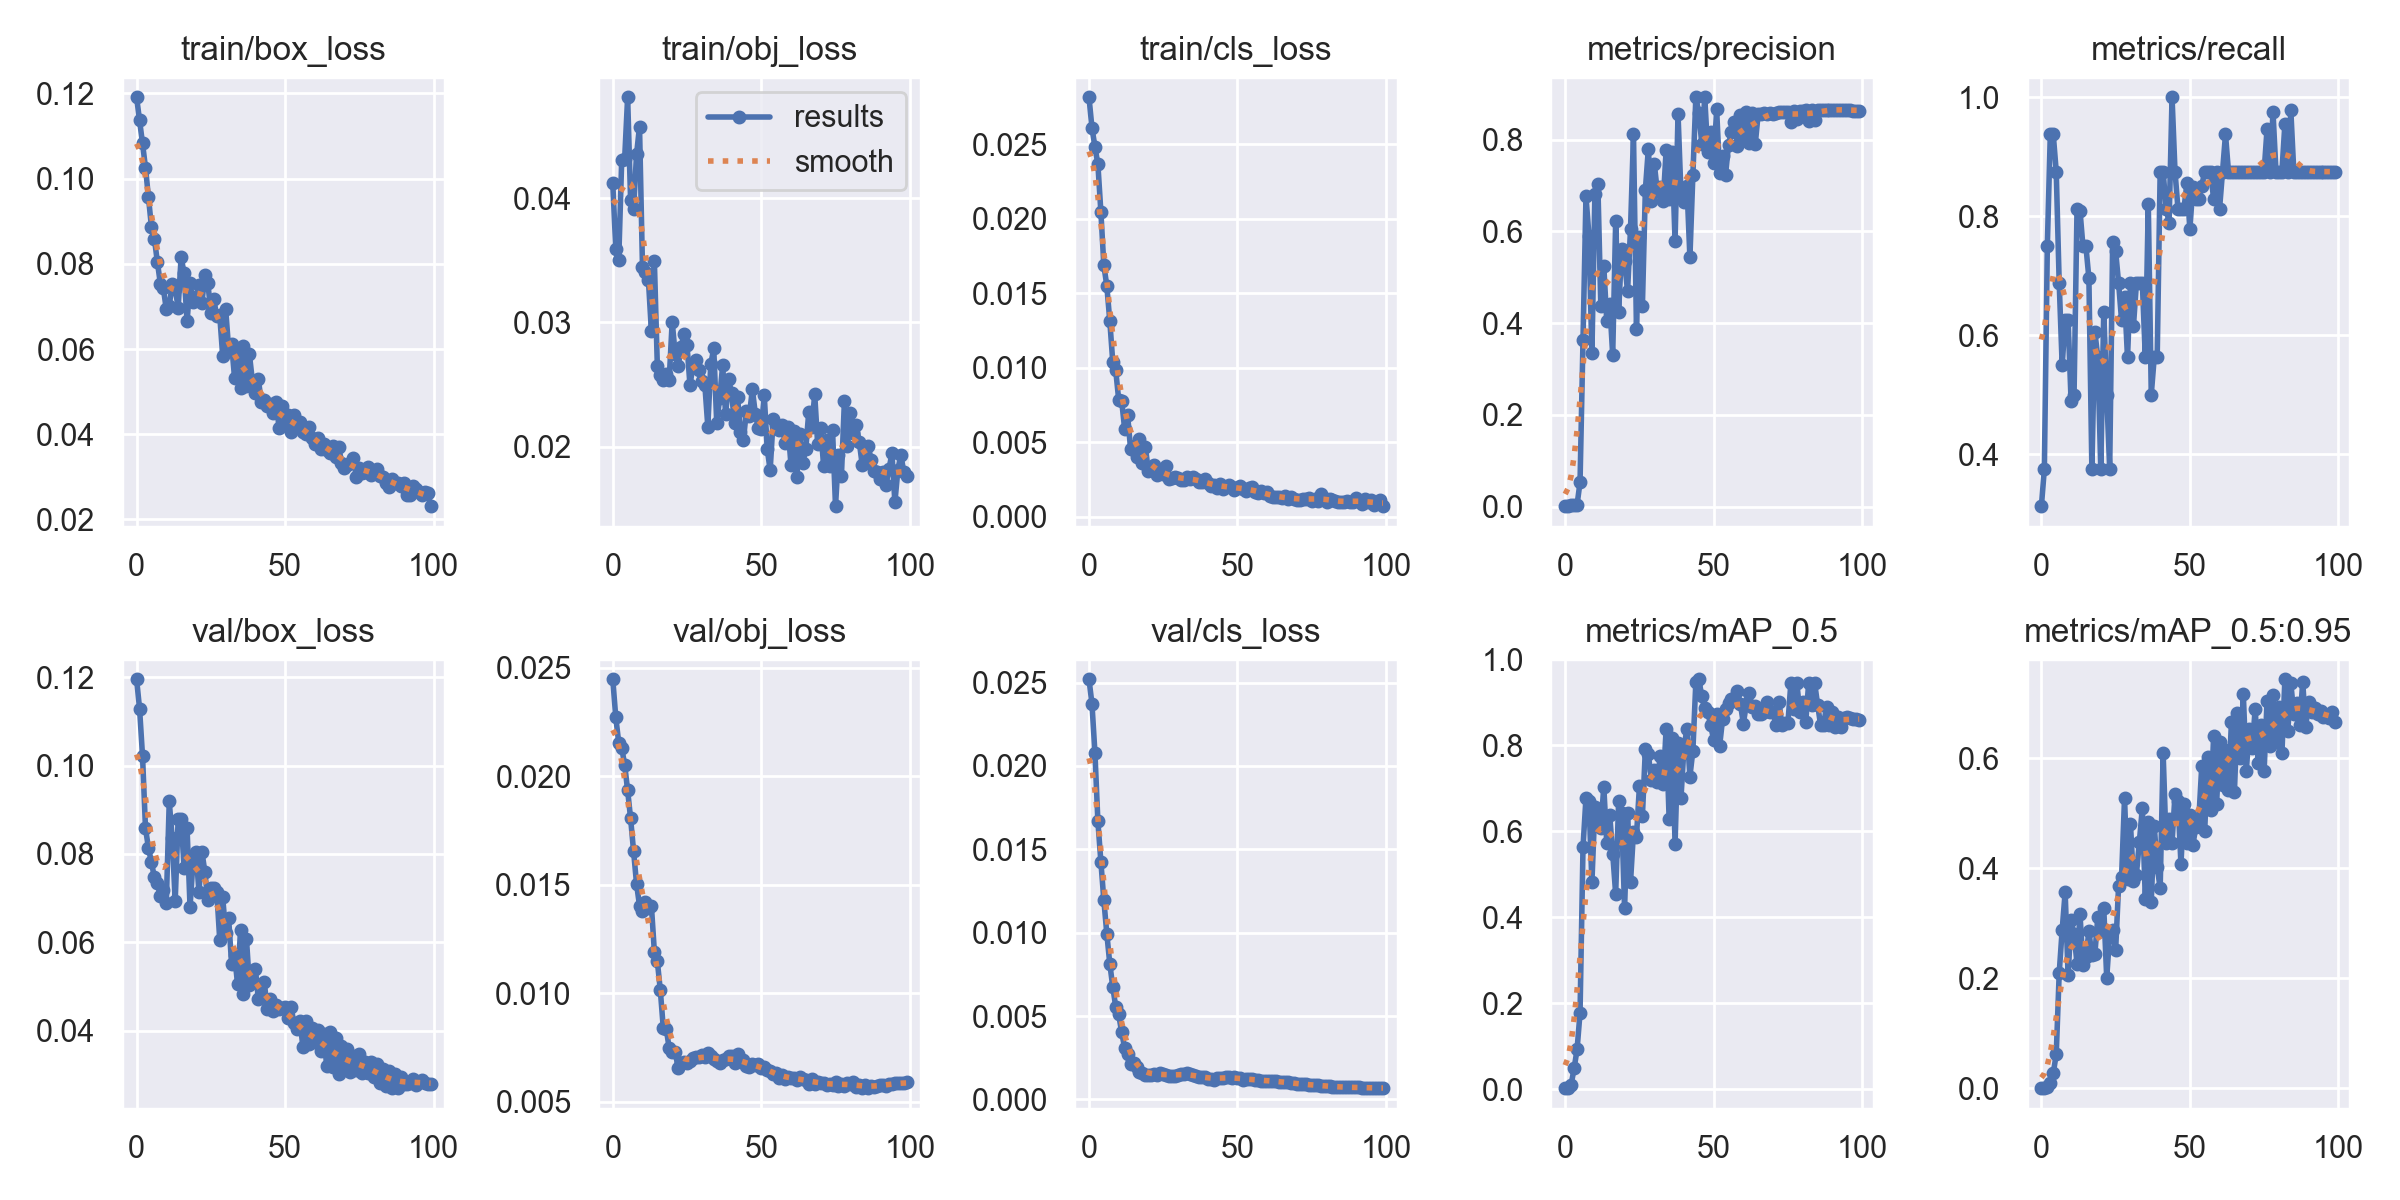

In [17]:
# Curvas do treino: perdas e métricas ao longo das 100 épocas (o joelho da curva mostra onde parou de melhorar)
from IPython.display import Image
Image('/content/yolov5/runs/train/vaca_caminhao/results.png')

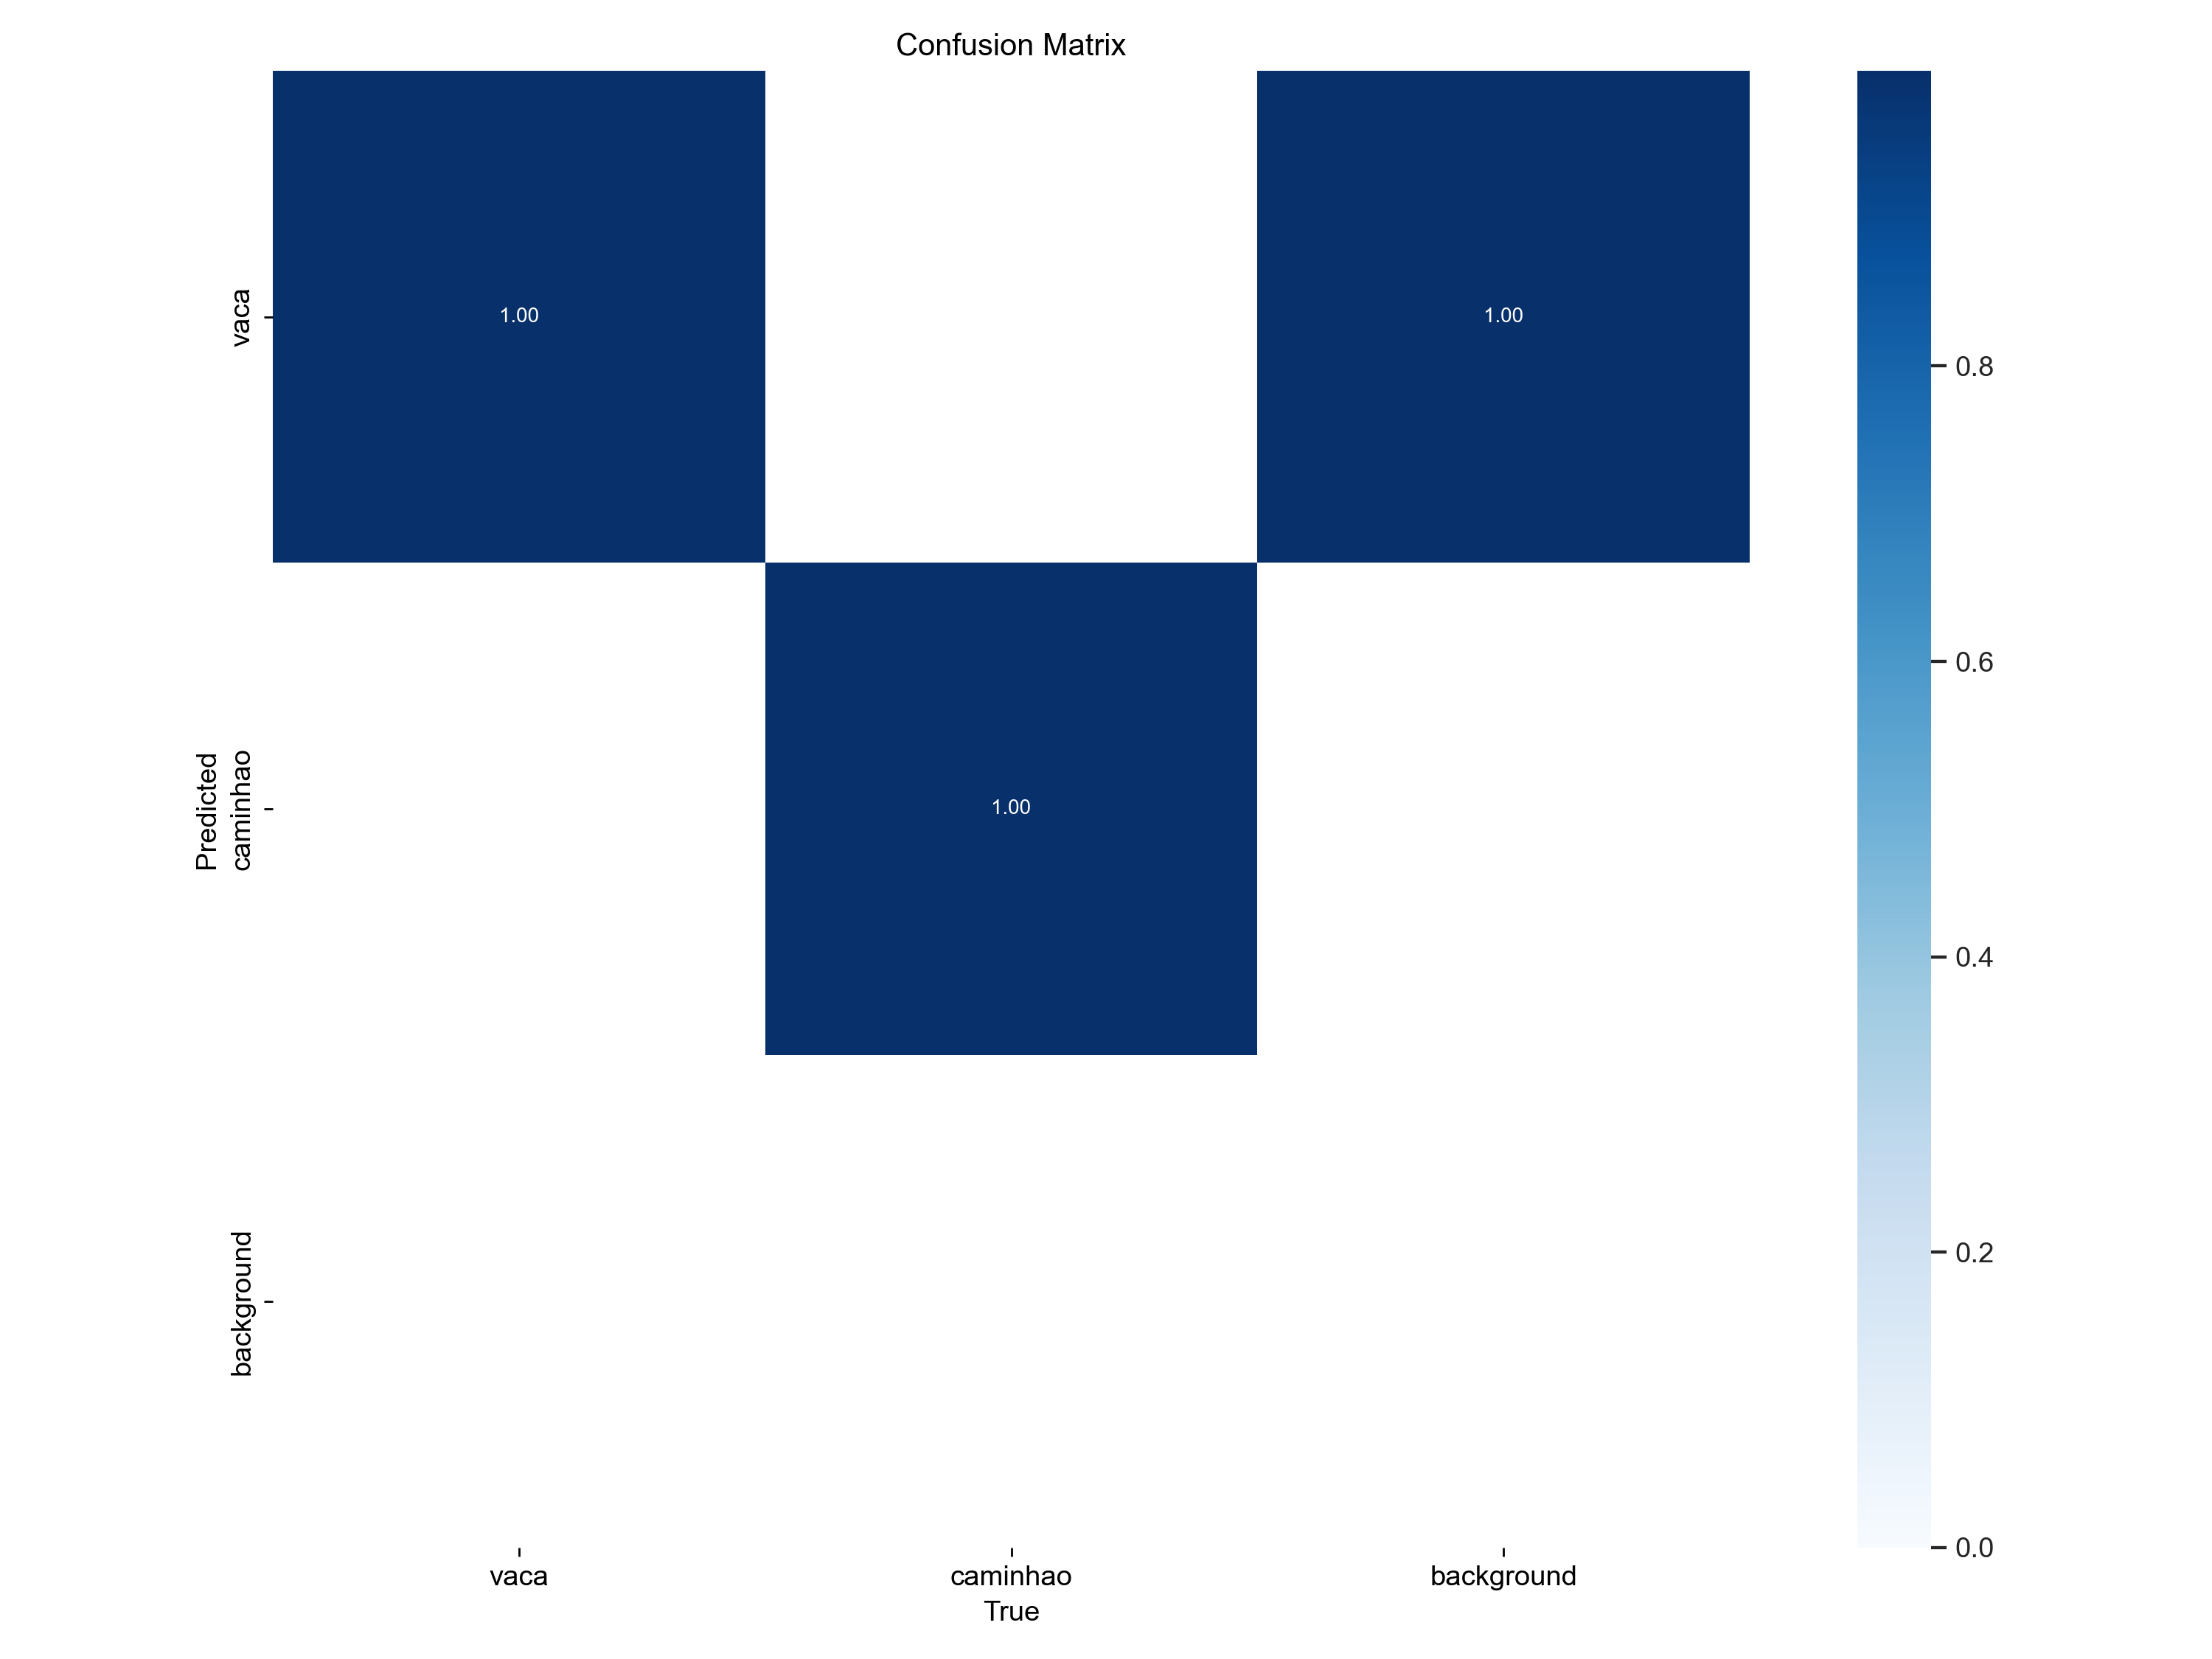

In [18]:
# Matriz de confusão: quantas vacas/caminhões o modelo acerta, confunde entre si ou perde para o fundo
Image('/content/yolov5/runs/train/vaca_caminhao/confusion_matrix.png')

### Avaliação no conjunto de teste (imagens que o modelo nunca viu)

`val.py --task test` usa a chave `test:` do `data.yaml` e reporta P, R, mAP@0.5 e mAP@0.5:0.95 por classe — é o número que vale para o cliente, porque o `best.pt` foi escolhido pela validação.

In [19]:
# Métrica final no teste (8 imagens, 15 instâncias) com o best.pt escolhido pela validação
!python val.py --weights runs/train/vaca_caminhao/weights/best.pt --data /content/dataset/data.yaml --task test --img 640 --name teste_final --exist-ok

val: data=/content/dataset/data.yaml, weights=['runs/train/vaca_caminhao/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=teste_final, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 f957879 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
test: Scanning /content/dataset/labels/test... 8 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8/8 234.1it/s 0.0s
test: New cache created: /content/dataset/labels/test.cache
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% ━━━━━━━━━━━━ 1/1 1.0it/s 1.0s
                   all          8         15      0.838      0.909      0.866      0.605
                  vaca          8         11      

## 6. Inferência com o modelo treinado

`detect.py` roda o `best.pt` nas imagens de teste e salva as imagens com as caixas em `runs/detect/custom_test/` — é o material que mostramos ao cliente. O log traz também o **tempo de inferência por imagem** (~19 ms na T4), usado depois na comparação da Entrega 2.

In [20]:
# Inferência no teste com o modelo treinado (conf 0.25, igual ao baseline COCO, para comparação justa)
!python detect.py --weights runs/train/vaca_caminhao/weights/best.pt --source /content/dataset/images/test --conf 0.25 --name custom_test --exist-ok

detect: weights=['runs/train/vaca_caminhao/weights/best.pt'], source=/content/dataset/images/test, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, update=False, project=runs/detect, name=custom_test, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 f957879 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 68 layers, 7,015,519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/dataset/images/test/caminhao_002.jpg: 640x640 1 caminhao, 15.0ms
image 2/8 /content/dataset/images/test/caminhao_006.jpg: 384x640 1 caminhao, 29.2ms
image 3/8 /content/dataset/images/test/caminhao_017.jpg: 448x640 1 caminhao, 28.0ms
image 4/8 /content/dataset/images/test/caminhao_019.jpg: 384x6

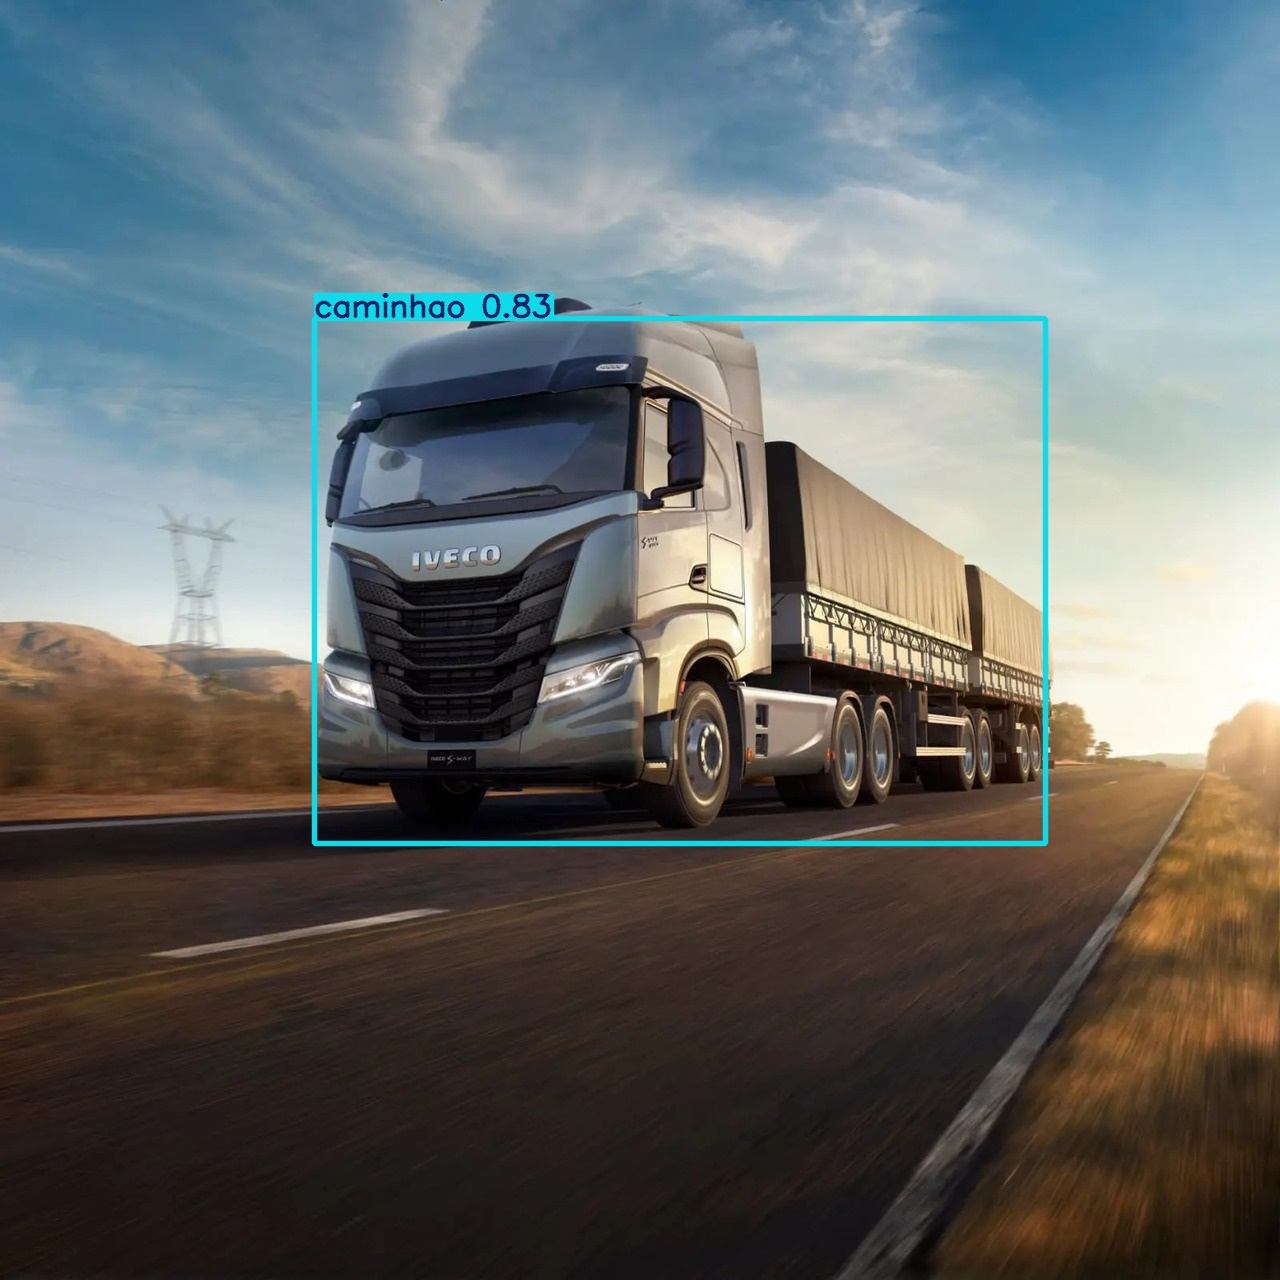

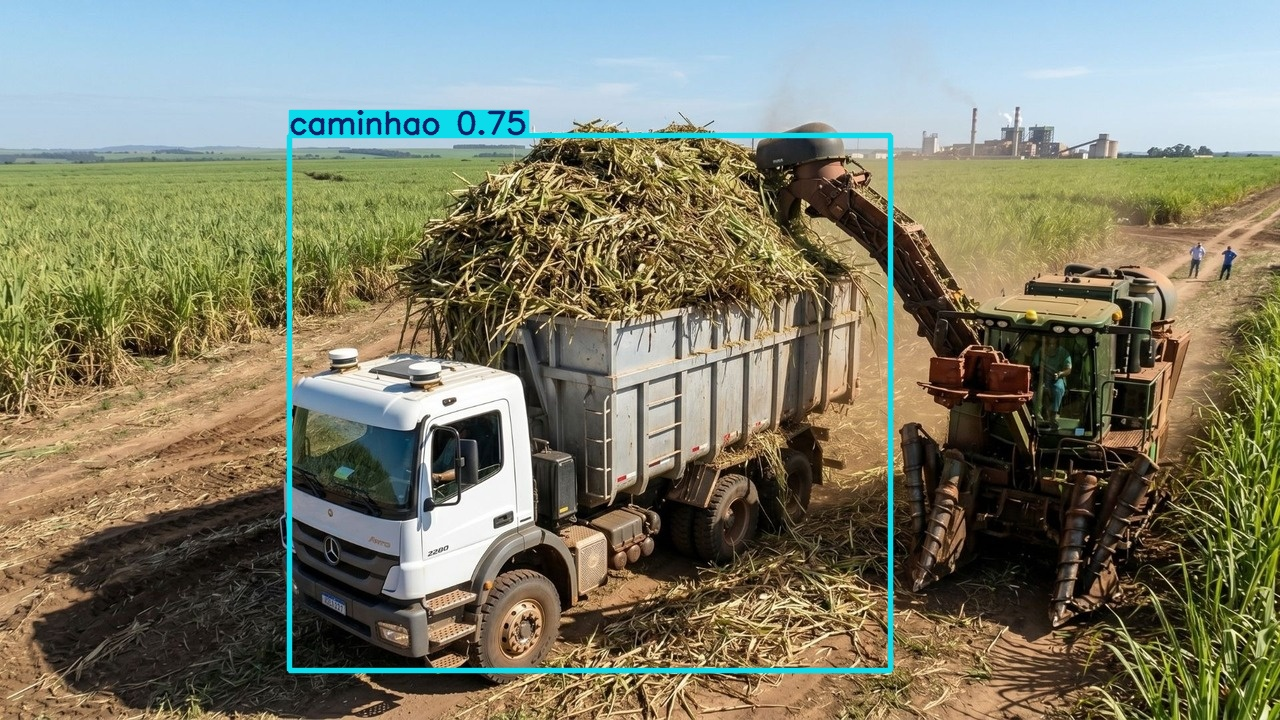

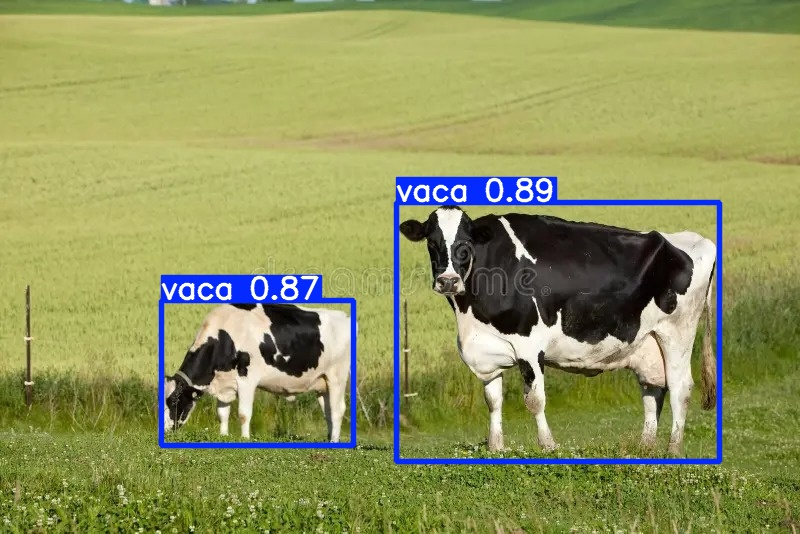

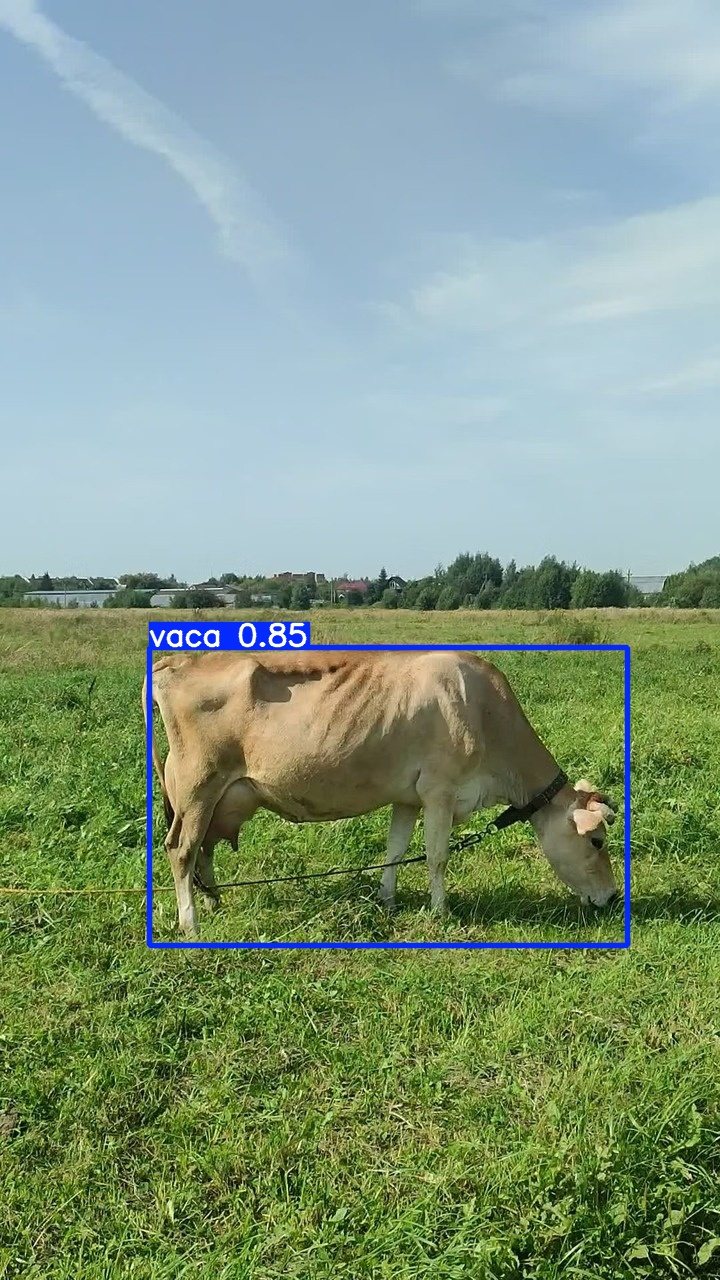

In [21]:
# Prints do teste: as 4 primeiras em ordem alfabética eram todas de caminhão, então mostramos 2 de cada classe
import glob
from IPython.display import Image
imagens = sorted(glob.glob('/content/yolov5/runs/detect/custom_test/*.jpg'))
for classe in ('caminhao', 'vaca'):
    for p in [i for i in imagens if classe in i][:2]:
        display(Image(p))

## 7. Comparação e conclusões

### Resultados

| | Val (8 img, 12 inst.) | Teste (8 img, 15 inst.) |
|---|---|---|
| Precision (geral) | 0,841 | 0,838 |
| Recall (geral) | 0,955 | 0,909 |
| mAP@0.5 | 0,945 | 0,866 |
| mAP@0.5:0.95 | 0,744 | 0,605 |

Por classe no **teste**: vaca (11 instâncias) P 0,890 / R 0,818 / mAP50 0,837 / mAP50-95 0,640; caminhão (4 instâncias) P 0,786 / R 1,0 / mAP50 0,895 / mAP50-95 0,569.

O treino (100 epochs, GPU T4) levou cerca de 5 minutos. O número de referência é o do **teste**: o `best.pt` foi escolhido pela validação, então os valores de val são otimistas.

### YOLO tradicional (COCO) × YOLO customizado

- **Contagem:** o modelo COCO detecta cada parte como um objeto: em `caminhao_019` contou 4 "trucks" na mesma imagem, contra 2 caixas do nosso modelo — a rotulagem do dataset alternou entre "o conjunto" e "cavalo + carreta", então essa contagem não serve como critério limpo de comparação.
- **Classes:** o baseline foi rodado filtrado em `cow`/`truck` (`--classes 19 7`), as duas classes do COCO que correspondem aos nossos objetos. O modelo customizado aprendeu o critério do nosso dataset (por exemplo, picape contada como caminhão), e por isso responde a nossa pergunta, não a do COCO.
- **Rebanhos:** no teste, o COCO chegou a 9 detecções em `vaca_013`, o nosso modelo a 6. Em rebanhos densos nem todos os animais foram rotulados, o que torna essa comparação imprecisa.
- **Ponto de partida:** o treino usou `yolov5s.pt` (pesos do COCO) como base (transfer learning). Boa parte do resultado vem desse conhecimento prévio, não só das 80 imagens.

### Limitações

- Dataset muito pequeno: 64 imagens de treino, 8 de validação e 8 de teste. O teste tem só 4 caminhões, então uma única caixa errada muda bastante as métricas. Os números são indicativos, não conclusivos.
- mAP50-95 do caminhão (0,569) bem abaixo do mAP50 (0,895): o modelo acha o caminhão, mas as caixas são menos justas, em parte pela ambiguidade de onde termina o conjunto cavalo + carreta.
- Em `vaca_035` o nosso modelo detectou 2 vacas onde havia 1 caixa rotulada; a `vaca_012`, que teve o mesmo sintoma num treino anterior, nesta execução saiu com 1 caixa só — a `vaca_012` está nos prints acima e a `vaca_035` pode ser aberta em `custom_test/` (falso positivo ou animal não rotulado).
- Imagens vindas da web, algumas com marca d'água, e rebanhos densos só parcialmente rotulados.
- Uma única execução de treino no notebook, sem repetição com outras sementes ou divisões — e os números mudam de um treino para o outro: duas execuções nossas deram mAP@0.5 de 0,887 e 0,866 no teste.

### Conclusão

Com poucas imagens, o fine-tuning já entrega um detector das duas classes com mAP@0.5 de 0,866 no teste e recall de 0,909, e segue a convenção de rotulagem do projeto, algo que o COCO sem treino não faz. Para melhorar: mais imagens (principalmente caminhões e rebanhos), rotulagem mais consistente e validação com divisão maior ou cruzada.

### Observações de execução

- O dataset vem da pasta pública do Drive (164 arquivos). O `gdown` não dá conta porque o Google limita a 50 arquivos por pasta — por isso o notebook cai no download pela API do Drive, que pede a autorização de leitura na primeira execução (a mensagem `Failed to retrieve` no log é esperada).
- A pasta está compartilhada como *"qualquer pessoa com o link"*, então o notebook roda em qualquer conta — é o que permite a correção executá-lo. Se o compartilhamento for revertido, o download pela API só funciona para quem recebeu a pasta.
- Os números acima são desta execução: com 8 imagens de teste, as métricas mudam de um treino para o outro (duas execuções nossas deram mAP@0.5 de 0,887 e 0,866).

### Ainda em aberto (issues do repositório)

- Segunda simulação de treino (**30 × 60 épocas**, issue #4), **CNN treinada do zero** (issue #7) e a tabela dos **4 critérios** da Entrega 2 (issue #8).


## 8. Simulações com números diferentes de épocas (issue #4)

O enunciado pede **ao menos duas simulações** com quantidades bem diferentes de épocas, comparando acurácia, erro e desempenho. Aqui rodamos o mesmo treino duas vezes — **30 e 60 épocas** — mantendo todo o resto igual (mesmos pesos iniciais, mesma resolução, mesmo lote), que é o que torna a comparação justa.

O treino principal de 100 épocas (seção 5) entra no final como referência de teto.

In [ ]:
# Simulação A — 30 épocas (só o --epochs muda em relação ao treino principal)
import time
t0 = time.time()
!python train.py --img 640 --batch 16 --epochs 30 --data /content/dataset/data.yaml --weights yolov5s.pt --patience 30 --name vaca_caminhao_30ep --exist-ok
print(f'>> 30 épocas: {(time.time() - t0) / 60:.1f} min de treino')

In [ ]:
# Simulação B — 60 épocas
t0 = time.time()
!python train.py --img 640 --batch 16 --epochs 60 --data /content/dataset/data.yaml --weights yolov5s.pt --patience 30 --name vaca_caminhao_60ep --exist-ok
print(f'>> 60 épocas: {(time.time() - t0) / 60:.1f} min de treino')

In [ ]:
# Comparação das simulações: lê o results.csv de cada treino e monta a tabela de métricas
import os
import pandas as pd

def resumo(nome):
    """Resume um treino: melhor época na validação, métricas finais e perdas de treino."""
    caminho = f'/content/yolov5/runs/train/{nome}/results.csv'
    if not os.path.exists(caminho):
        return None
    r = pd.read_csv(caminho)
    r.columns = [c.strip() for c in r.columns]  # o header do YOLOv5 vem com espaço depois da vírgula
    melhor = r.loc[r['metrics/mAP_0.5'].idxmax()]
    fim = r.iloc[-1]
    return {
        'épocas rodadas': len(r),
        'melhor mAP50 (val)': round(melhor['metrics/mAP_0.5'], 3),
        'época do melhor': int(melhor['epoch']),
        'mAP50 final (val)': round(fim['metrics/mAP_0.5'], 3),
        'mAP50-95 final (val)': round(fim['metrics/mAP_0.5:0.95'], 3),
        'P final (val)': round(fim['metrics/precision'], 3),
        'R final (val)': round(fim['metrics/recall'], 3),
        'box_loss final (treino)': round(fim['train/box_loss'], 4),
        'obj_loss final (treino)': round(fim['train/obj_loss'], 4),
        'cls_loss final (treino)': round(fim['train/cls_loss'], 4),
    }

tabela = pd.DataFrame({nome: resumo(nome) for nome in ('vaca_caminhao_30ep', 'vaca_caminhao_60ep', 'vaca_caminhao')})
tabela.columns = ['30 épocas', '60 épocas', '100 épocas (seção 5)']
tabela.index.name = 'métrica'
display(tabela)

In [ ]:
# Cada simulação é avaliada no teste com o seu próprio best.pt
for nome in ('vaca_caminhao_30ep', 'vaca_caminhao_60ep'):
    print(f'==== {nome} — teste ====')
    !python val.py --weights runs/train/{nome}/weights/best.pt --data /content/dataset/data.yaml --task test --img 640 --name teste_{nome} --exist-ok | tail -4

In [ ]:
# Contagem de detecções nas imagens de teste, nas duas versões (para comparar o comportamento)
for nome in ('vaca_caminhao_30ep', 'vaca_caminhao_60ep'):
    print(f'==== detecções — {nome} ====')
    !python detect.py --weights runs/train/{nome}/weights/best.pt --source /content/dataset/images/test --conf 0.25 --name detect_{nome} --exist-ok | grep '^image'

### Leitura dos resultados

- **Mais épocas ajudam até certo ponto.** Compare as colunas de 30, 60 e 100 épocas na tabela acima: o `mAP50 final` da validação, as perdas de treino e a `época do melhor`. Com 64 imagens de treino, o ganho tende a se esgotar rápido — quando a `época do melhor` fica bem antes da última, é sinal de que treinar mais não estava melhorando a validação.
- **Overfitting** aparece quando a perda de treino continua caindo enquanto a validação estaciona ou piora: nesse caso o `mAP50 final` fica abaixo do `melhor mAP50`.
- **Desempenho**: o tempo de treino é praticamente proporcional ao número de épocas (veja os prints das duas execuções — a de 60 leva cerca do dobro da de 30). Em um cliente real isso é custo de GPU por treino.
- **Qual versão escolher**: a de 100 épocas (seção 7) entrega o melhor resultado deste dataset; a de 60 é o meio-termo entre qualidade e custo; a de 30 serve como linha de base barata. O enunciado não tem resposta única — depende do orçamento de treino do cliente.

## 9. CNN treinada do zero (issue #7)

Abordagem concorrente da YOLO para a mesma base: em vez de **detectar e localizar** (bounding boxes), uma **CNN de classificação** apenas diz a qual classe a imagem pertence — `vaca` ou `caminhao`. Cada imagem do dataset tem uma única classe, então o rótulo vem do próprio nome do arquivo, e usamos **o mesmo split** da Entrega 1 (32/4/4 por classe).

Arquitetura construída do zero (Keras/TensorFlow): três blocos `Conv2D + MaxPooling`, `Flatten`, camadas densas e saída sigmoide para classificação binária. Como são 64 imagens de treino, a **augmentação** (rotação, flip horizontal e zoom) é o que impede a rede de decorar as imagens.

In [ ]:
# Índice das imagens: classe pelo prefixo do nome (vaca_* ou caminhao_*), mesmo split da Entrega 1
import glob
import os
import pandas as pd

def indice(split):
    linhas = [{'filename': p, 'classe': 'vaca' if os.path.basename(p).startswith('vaca') else 'caminhao'}
              for p in sorted(glob.glob(f'{LOCAL}/images/{split}/*.jpg'))]
    return pd.DataFrame(linhas)

df_treino, df_val, df_teste = indice('train'), indice('val'), indice('test')
print('treino | validação | teste:', len(df_treino), '|', len(df_val), '|', len(df_teste))
print('classes no treino:', df_treino['classe'].value_counts().to_dict())

In [ ]:
# Geradores: augmentação só no treino; validação e teste apenas normalizados
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG, LOTE = 224, 8  # entrada da CNN e tamanho do lote
ger_treino = ImageDataGenerator(rescale=1/255, rotation_range=20, horizontal_flip=True, zoom_range=0.2) \
    .flow_from_dataframe(df_treino, x_col='filename', y_col='classe', target_size=(IMG, IMG),
                         batch_size=LOTE, class_mode='binary', seed=0)
ger_val = ImageDataGenerator(rescale=1/255) \
    .flow_from_dataframe(df_val, x_col='filename', y_col='classe', target_size=(IMG, IMG),
                         batch_size=LOTE, class_mode='binary', shuffle=False)
ger_teste = ImageDataGenerator(rescale=1/255) \
    .flow_from_dataframe(df_teste, x_col='filename', y_col='classe', target_size=(IMG, IMG),
                         batch_size=LOTE, class_mode='binary', shuffle=False)
print('classes (ordem alfabética):', ger_treino.class_indices)

In [ ]:
# CNN do zero: 3 blocos Conv2D + MaxPooling, densas e saída sigmoide (1 = vaca)
import time
import tensorflow as tf
from tensorflow.keras import layers, models

tf.random.set_seed(0)
modelo = models.Sequential([
    layers.Input((IMG, IMG, 3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'), layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid'),
])
modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
modelo.summary()

t0 = time.time()
hist = modelo.fit(ger_treino, validation_data=ger_val, epochs=40,
                  callbacks=[tf.keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_loss')])
print(f'>> treino da CNN: {(time.time() - t0) / 60:.2f} min')

In [ ]:
# Curvas de perda e acurácia: treino contra validação (é o que mostra o overfitting)
import matplotlib.pyplot as plt

fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].plot(hist.history['loss'], label='treino'); eixos[0].plot(hist.history['val_loss'], label='validação')
eixos[0].set_title('perda'); eixos[0].set_xlabel('época'); eixos[0].legend()
eixos[1].plot(hist.history['accuracy'], label='treino'); eixos[1].plot(hist.history['val_accuracy'], label='validação')
eixos[1].set_title('acurácia'); eixos[1].set_xlabel('época'); eixos[1].legend()
plt.tight_layout(); plt.show()

In [ ]:
# Avaliação no teste: acurácia, matriz de confusão e tempo de inferência por imagem
import numpy as np
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

ger_teste.reset()
prob = modelo.predict(ger_teste, verbose=0).ravel()
previsto = (prob > 0.5).astype(int)          # 1 = vaca, conforme a ordem alfabética do gerador
verdadeiro = ger_teste.classes
acertos = int((previsto == verdadeiro).sum())
print(f'acurácia no teste: {acertos / len(verdadeiro):.3f} ({acertos}/{len(verdadeiro)} imagens)')

ConfusionMatrixDisplay(confusion_matrix(verdadeiro, previsto),
                       display_labels=list(ger_teste.class_indices)).plot(cmap='Blues')
plt.show()

# tempo de inferência: média por imagem (comparável ao que o detect.py reporta)
uma = np.expand_dims(next(iter(ger_teste))[0][0], 0)
modelo.predict(uma, verbose=0)               # aquece o modelo
t0 = time.time()
for _ in range(20):
    modelo.predict(uma, verbose=0)
print(f'inferência da CNN: {(time.time() - t0) / 20 * 1000:.1f} ms por imagem')

### Leitura dos resultados

- A CNN resolve a tarefa **mais simples**: dizer se a imagem tem vaca ou caminhão, sem localizar nada. A acurácia alta no teste é esperada por isso — mas cuidado com a amostra: são **8 imagens** (4 de cada classe), então **um erro muda a acurácia em 12,5 pontos**.
- A YOLO entrega mais: além da classe, a **caixa** de cada objeto, e vários na mesma imagem (rebanhos). Em troca, exige rotulação de caixas, treino mais caro e inferência mais pesada.
- **Quando cada uma vence**: para "tem gado na câmera?" ou triagem rápida de muitos quadros, a CNN é mais simples, leve e barata de treinar; para contar, medir ou localizar, a detecção é necessária. Classificação e detecção respondem a perguntas diferentes.
- O tempo de inferência da CNN acima é de **uma imagem por vez**; a YOLO reportada na seção 7 é por imagem dentro de um lote. A comparação direta entre as duas está consolidada na seção 10.

In [22]:
# Guarda no Drive o que o notebook gerou (runs/ com pesos, results.csv, gráficos e imagens detectadas)
dest = f'{DRIVE_ROOT}/resultados'
shutil.copytree('/content/yolov5/runs', dest, dirs_exist_ok=True)
print('salvo em', dest)

salvo em /content/drive/MyDrive/Fase 6 - Cap 1/resultados
